In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import hdbscan
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [121]:
datasets = [
    'SPY',   # equities
    'QQQ',   # tech
    'IWM',   # small cap
    'TLT',   # bonds
    'GLD',   # gold
    'XLE',   # energy
    'XLF',   # financials
    'XLK'    # tech sector
]

df = yf.download(datasets, start='2010-01-01', end='2024-06-30')

# work only with close prices for all tickers
close = df['Close'].squeeze()

# percentage returns for each ticker
returns = close.pct_change()
returns = returns.dropna()

print(returns.head())

features = pd.DataFrame(index=close.index)

rolling_window = 20

# aggregate features across all datasets
#features['volatility'] = returns.rolling(window=rolling_window).std().mean(axis=1)
#features['skewness'] = returns.rolling(window=rolling_window).skew().mean(axis=1)
#features['avg_return'] = returns.rolling(window=rolling_window).mean().mean(axis=1)
#features['drawdown'] = (close / close.rolling(rolling_window).max() - 1).mean(axis=1)
#features['trend'] = (close / close.rolling(rolling_window).mean()).mean(axis=1)
#features['vol_change'] = features['volatility'].diff()
#features['dispersion'] = returns.std(axis=1)

features = pd.DataFrame(index=close.index)

# 1. Market volatility (core risk signal)
features['volatility'] = returns.rolling(rolling_window).std().mean(axis=1)

# 2. Market return (direction)
features['avg_return'] = returns.rolling(rolling_window).mean().mean(axis=1)

# 3. Cross-asset dispersion (VERY important)
features['dispersion'] = returns.std(axis=1)

# 4. Correlation breakdown (huge for regimes)
features['correlation'] = returns.rolling(rolling_window).corr().groupby(level=0).mean().mean(axis=1)

# 5. Equity vs bond spread (risk-on/off signal)
features['equity_bond_spread'] = (
    returns[['SPY','QQQ','IWM']].mean(axis=1) -
    returns['TLT']
)

# 6. Drawdown (stress indicator)
features['drawdown'] = (close / close.rolling(rolling_window).max() - 1).mean(axis=1)

# 7. Volatility change (regime transitions)
features['vol_change'] = features['volatility'].diff()

features = features.dropna()
print(features.head())

[*********************100%***********************]  8 of 8 completed


Ticker           GLD       IWM       QQQ       SPY       TLT       XLE  \
Date                                                                     
2010-01-05 -0.000911 -0.003438  0.000000  0.002647  0.006458  0.008162   
2010-01-06  0.016500 -0.000941 -0.006032  0.000704 -0.013387  0.011975   
2010-01-07 -0.006188  0.007378  0.000650  0.004221  0.001683 -0.001500   
2010-01-08  0.004963  0.005454  0.008231  0.003328 -0.000448  0.006510   
2010-01-11  0.013289 -0.004030 -0.004081  0.001397 -0.005488 -0.001327   

Ticker           XLF       XLK  
Date                            
2010-01-05  0.018380 -0.001289  
2010-01-06  0.002005 -0.011187  
2010-01-07  0.021347 -0.003917  
2010-01-08 -0.005878  0.006553  
2010-01-11  0.000657 -0.003906  
            volatility  avg_return  dispersion  correlation  \
Date                                                          
2010-02-03    0.012333   -0.001824    0.006095     0.523340   
2010-02-04    0.013934   -0.003255    0.018868     0.545810  

In [122]:
# standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [131]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
regime = clusterer.fit_predict(scaled_features)

features_hdbscan = pd.DataFrame(
	scaled_features,
	index=features.index,
	columns=features.columns
)
features_hdbscan['regime'] = regime

In [132]:
#calculate silhouette score
mask_noise = regime != -1
features_hdbscan_filtered = features_hdbscan[mask_noise]
num_clusters = len(set(regime)) - (1 if -1 in regime else 0)

print(num_clusters)

if num_clusters >= 2:
    score = silhouette_score(scaled_features[mask_noise], regime[mask_noise])
    print(f'Silhouette Score: {score}')


6
Silhouette Score: 0.22964506921018107


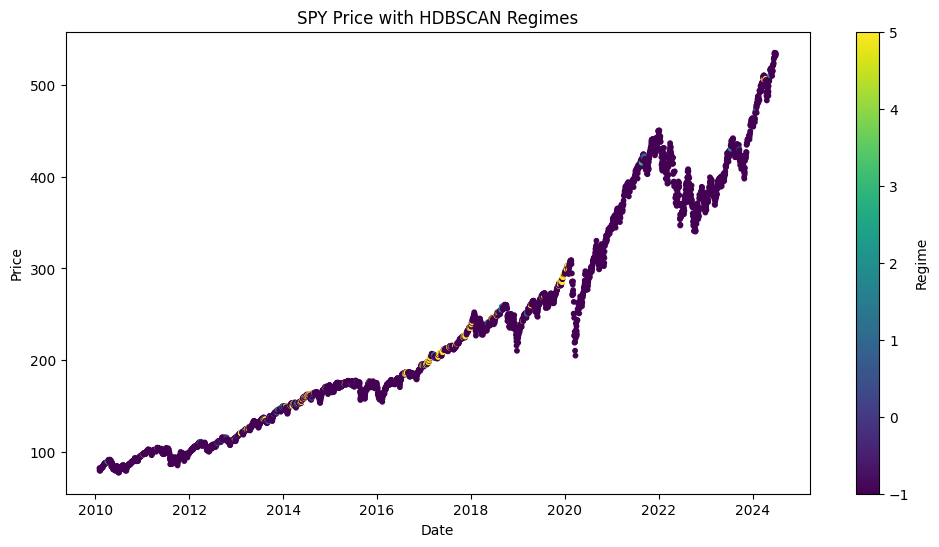

In [133]:
plt.figure(figsize=(12, 6))
plt.scatter(features.index, close['SPY'].loc[features.index], c=regime, cmap='viridis', s=10)
plt.title("SPY Price with HDBSCAN Regimes")
plt.xlabel("Date")
plt.ylabel("Price")
plt.colorbar(label="Regime")
plt.show()

In [126]:
# find optimal min_samples and min_cluster_size
best_score = -1
best_params = None

for min_samples in range(5, 21, 5):
    for min_cluster_size in range(5, 21, 5):
        clusterer = hdbscan.HDBSCAN(min_samples=min_samples, min_cluster_size=min_cluster_size)
        regime = clusterer.fit_predict(scaled_features)
        
        mask_noise = regime != -1
        num_clusters = len(set(regime)) - (1 if -1 in regime else 0)

        if num_clusters >= 2:
            score = silhouette_score(scaled_features[mask_noise], regime[mask_noise])
            print(f'min_samples: {min_samples}, min_cluster_size: {min_cluster_size}, Silhouette Score: {score}, Clusters: {num_clusters}')
            
            if score > best_score:
                best_score = score
                best_params = (min_samples, min_cluster_size)

print(f'Best parameters: min_samples={best_params[0]}, min_cluster_size={best_params[1]}')

min_samples: 5, min_cluster_size: 5, Silhouette Score: 0.34008970326756516, Clusters: 3
min_samples: 5, min_cluster_size: 10, Silhouette Score: 0.22964506921018107, Clusters: 6
min_samples: 5, min_cluster_size: 15, Silhouette Score: 0.4025741326304199, Clusters: 3
min_samples: 5, min_cluster_size: 20, Silhouette Score: 0.4025741326304199, Clusters: 3
min_samples: 10, min_cluster_size: 5, Silhouette Score: 0.46957591332379606, Clusters: 2
min_samples: 10, min_cluster_size: 10, Silhouette Score: 0.46957591332379606, Clusters: 2
min_samples: 10, min_cluster_size: 15, Silhouette Score: 0.46957591332379606, Clusters: 2
min_samples: 10, min_cluster_size: 20, Silhouette Score: 0.46957591332379606, Clusters: 2
min_samples: 15, min_cluster_size: 5, Silhouette Score: 0.28800636253784656, Clusters: 3
min_samples: 15, min_cluster_size: 10, Silhouette Score: 0.5197267919856542, Clusters: 2
min_samples: 15, min_cluster_size: 15, Silhouette Score: 0.5197267919856542, Clusters: 2
min_samples: 15, min_

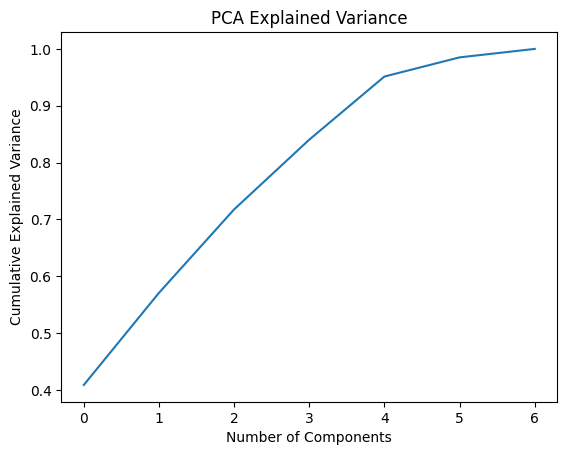

In [143]:
# PCA the features
pca = PCA().fit(scaled_features)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

# use PCA to reduce dimensionality for visualization
pca = PCA(n_components=2).fit_transform(scaled_features)

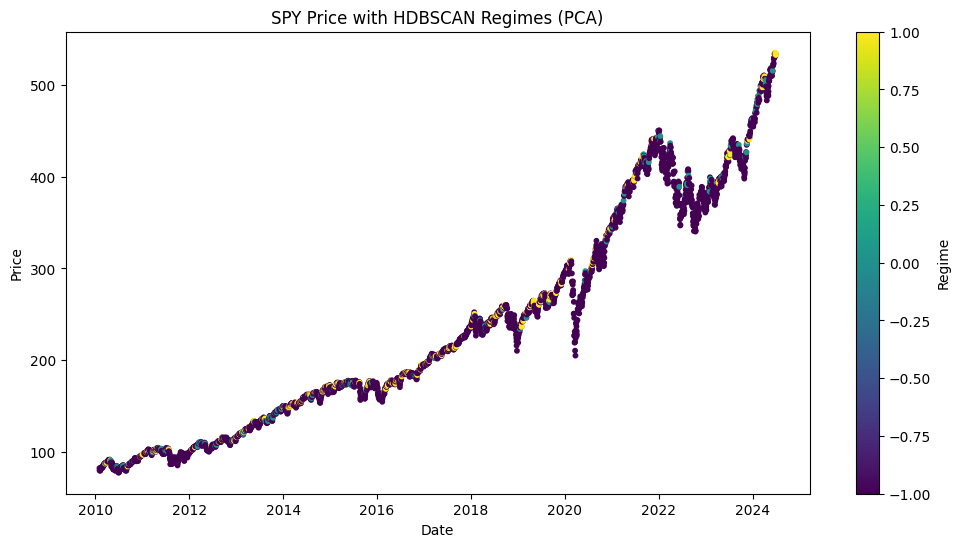

: 

In [ ]:
# Run hdbscan on PCA features
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
regime = clusterer.fit_predict(pca)

features_hdbscan_pca = pd.DataFrame(
    pca,
    columns=[f'PC{i+1}' for i in range(pca.shape[1])]
)
features_hdbscan_pca['regime'] = regime

plt.figure(figsize=(12, 6))
plt.scatter(features.index, close['SPY'].loc[features.index], c=regime, cmap='viridis', s=10)
plt.title("SPY Price with HDBSCAN Regimes (PCA)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.colorbar(label="Regime")
plt.show()

In [140]:
# with pca features, find optimal min_samples and min_cluster_size
best_score = -1
best_params = None

for min_samples in range(5, 21, 5):
    for min_cluster_size in range(5, 100, 5):
        clusterer = hdbscan.HDBSCAN(min_samples=min_samples, min_cluster_size=min_cluster_size)
        regime = clusterer.fit_predict(pca)
        
        mask_noise = regime != -1
        num_clusters = len(set(regime)) - (1 if -1 in regime else 0)

        if num_clusters >= 2:
            score = silhouette_score(pca[mask_noise], regime[mask_noise])
            print(f'min_samples: {min_samples}, min_cluster_size: {min_cluster_size}, Silhouette Score: {score}, Clusters: {num_clusters}')
            
            if score > best_score:
                best_score = score
                best_params = (min_samples, min_cluster_size)
print(f'Best parameters for PCA features: min_samples={best_params[0]}, min_cluster_size={best_params[1]}')

min_samples: 5, min_cluster_size: 5, Silhouette Score: 0.7750754989250161, Clusters: 2
min_samples: 5, min_cluster_size: 10, Silhouette Score: 0.21634482344497688, Clusters: 3
min_samples: 5, min_cluster_size: 15, Silhouette Score: 0.22261487800421753, Clusters: 2
min_samples: 5, min_cluster_size: 20, Silhouette Score: 0.22408069145499526, Clusters: 2
min_samples: 5, min_cluster_size: 25, Silhouette Score: 0.4460458254939577, Clusters: 2
min_samples: 5, min_cluster_size: 30, Silhouette Score: 0.4460458254939577, Clusters: 2
min_samples: 5, min_cluster_size: 35, Silhouette Score: 0.4460458254939577, Clusters: 2
min_samples: 5, min_cluster_size: 40, Silhouette Score: 0.4460458254939577, Clusters: 2
min_samples: 5, min_cluster_size: 45, Silhouette Score: 0.4460458254939577, Clusters: 2
min_samples: 5, min_cluster_size: 50, Silhouette Score: 0.4460458254939577, Clusters: 2
min_samples: 5, min_cluster_size: 55, Silhouette Score: 0.4460458254939577, Clusters: 2
min_samples: 5, min_cluster_si